# GraphSAGE Inference Speed Analysis

This notebook analyzes the inference speed bottlenecks for the GraphSAGE models trained on different surface code distances (d=3 to d=13).

**Goals:**
1. Profile the forward pass to identify bottlenecks
2. Analyze how graph size scales with distance
3. Quantify the impact of each component on inference time
4. Identify optimization opportunities

## 1. Setup

In [ ]:
import sys
import json
import time
from pathlib import Path
from typing import Dict, List, Tuple

# Path setup
BASE_PATH = Path('../..')
sys.path.insert(0, str(BASE_PATH))

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool

from models import (
    SurfaceCodeSampler,
    SparseGraph,
    GraphSAGE,
    GraphSAGEModel,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

ModuleNotFoundError: No module named 'torch_scatter'

## 2. Load Models and Analyze Architecture

In [7]:
# Distances to analyze
DISTANCES = [3, 5, 7, 9, 11, 13]

# Load models
models_dir = BASE_PATH / "gSAGE" / "distances" / "models" / "revised_training"
models = {}

for d in DISTANCES:
    model_path = models_dir / f"d{d}.pt"
    if model_path.exists():
        model = GraphSAGE(nickname=f'd{d}', device=device)
        model.load(str(model_path))
        models[d] = model
        print(f"d={d}: Loaded {model}")
    else:
        print(f"d={d}: Model not found at {model_path}")

print(f"\nLoaded {len(models)} models")

GraphSAGE initialized: GraphSAGE(nickname='d3', in_channels=5, hidden_dim=128, num_layers=4)
Model loaded: GraphSAGE(nickname='d3', in_channels=5, hidden_dim=128, num_layers=5, aggr='max', loaded_from='d3.pt')
d=3: Loaded GraphSAGE(nickname='d3', in_channels=5, hidden_dim=128, num_layers=5, aggr='max', loaded_from='d3.pt')
GraphSAGE initialized: GraphSAGE(nickname='d5', in_channels=5, hidden_dim=128, num_layers=4)
Model loaded: GraphSAGE(nickname='d5', in_channels=5, hidden_dim=128, num_layers=5, aggr='max', loaded_from='d5.pt')
d=5: Loaded GraphSAGE(nickname='d5', in_channels=5, hidden_dim=128, num_layers=5, aggr='max', loaded_from='d5.pt')
GraphSAGE initialized: GraphSAGE(nickname='d7', in_channels=5, hidden_dim=128, num_layers=4)
Model loaded: GraphSAGE(nickname='d7', in_channels=5, hidden_dim=128, num_layers=5, aggr='max', loaded_from='d7.pt')
d=7: Loaded GraphSAGE(nickname='d7', in_channels=5, hidden_dim=128, num_layers=5, aggr='max', loaded_from='d7.pt')
GraphSAGE initialized: Gr

In [8]:
# Analyze model architecture
if models:
    sample_model = list(models.values())[0].model
    print("Model Architecture:")
    print(f"  Input channels: {sample_model.in_channels}")
    print(f"  Hidden dim: {sample_model.hidden_dim}")
    print(f"  Num layers: {sample_model.num_layers}")
    print(f"  Aggregation: {sample_model.aggr}")
    print(f"  Dropout: {sample_model.dropout_rate}")
    print(f"\nTotal parameters: {sum(p.numel() for p in sample_model.parameters()):,}")
    
    # Breakdown by layer type
    print("\nParameter breakdown:")
    conv_params = sum(p.numel() for conv in sample_model.convs for p in conv.parameters())
    bn_params = sum(p.numel() for bn in sample_model.bns for p in bn.parameters())
    fc_params = sum(p.numel() for p in sample_model.fc1.parameters()) + \
                sum(p.numel() for p in sample_model.fc2.parameters())
    print(f"  Conv layers: {conv_params:,} ({100*conv_params/sum(p.numel() for p in sample_model.parameters()):.1f}%)")
    print(f"  BatchNorm: {bn_params:,}")
    print(f"  FC layers: {fc_params:,}")

Model Architecture:
  Input channels: 5
  Hidden dim: 128
  Num layers: 5
  Aggregation: max
  Dropout: 0.0

Total parameters: 142,593

Parameter breakdown:
  Conv layers: 132,992 (93.3%)
  BatchNorm: 1,280
  FC layers: 8,321


## 3. Graph Size Scaling Analysis

How does the graph size (nodes, edges) scale with code distance?

In [9]:
# Calculate theoretical detector counts and actual graph sizes
print("Detector count scaling with distance:")
print("="*60)

detector_counts = {}
for d in DISTANCES:
    num_stabilizers = d**2 - 1
    num_rounds = d
    num_detectors = num_stabilizers * num_rounds
    detector_counts[d] = num_detectors
    print(f"d={d:2d}: {num_stabilizers:4d} stabilizers × {num_rounds} rounds = {num_detectors:5d} detectors")

print("\nScaling factor (relative to d=3):")
base = detector_counts[3]
for d in DISTANCES:
    print(f"d={d:2d}: {detector_counts[d]/base:.1f}x")

Detector count scaling with distance:
d= 3:    8 stabilizers × 3 rounds =    24 detectors
d= 5:   24 stabilizers × 5 rounds =   120 detectors
d= 7:   48 stabilizers × 7 rounds =   336 detectors
d= 9:   80 stabilizers × 9 rounds =   720 detectors
d=11:  120 stabilizers × 11 rounds =  1320 detectors
d=13:  168 stabilizers × 13 rounds =  2184 detectors

Scaling factor (relative to d=3):
d= 3: 1.0x
d= 5: 5.0x
d= 7: 14.0x
d= 9: 30.0x
d=11: 55.0x
d=13: 91.0x


In [10]:
# Generate sample graphs to measure actual node/edge counts
print("\nActual graph sizes (at p=0.005):")
print("="*60)

graph_builder = SparseGraph(k_neighbors=6, device=device)

sampler = SurfaceCodeSampler(p=0.005, device=device)

graph_stats = {}
for d in DISTANCES:
    # Generate 1000 samples using sample(d=..., num_samples=...)
    num_samples = 1000
    detections_batch, labels_batch = sampler.sample(d=d, num_samples=num_samples)
    
    node_counts = []
    edge_counts = []
    
    for i in range(num_samples):
        graph = graph_builder.to_pyg(detections_batch[i], labels_batch[i])
        node_counts.append(graph.x.shape[0])
        edge_counts.append(graph.edge_index.shape[1])
    
    stats = {
        'detectors': detector_counts[d],
        'avg_nodes': np.mean(node_counts),
        'std_nodes': np.std(node_counts),
        'avg_edges': np.mean(edge_counts),
        'std_edges': np.std(edge_counts),
        'sparsity': np.mean(node_counts) / detector_counts[d],
    }
    graph_stats[d] = stats
    
    print(f"d={d:2d}: {stats['avg_nodes']:6.1f} ± {stats['std_nodes']:5.1f} nodes, "
          f"{stats['avg_edges']:7.1f} ± {stats['std_edges']:6.1f} edges "
          f"(sparsity: {stats['sparsity']*100:.1f}%)")


Actual graph sizes (at p=0.005):
SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)
d= 3:    1.4 ±   1.6 nodes,     3.2 ±    6.6 edges (sparsity: 5.9%)
d= 5:    8.3 ±   4.0 nodes,    46.8 ±   27.7 edges (sparsity: 6.9%)
d= 7:   24.8 ±   7.5 nodes,   148.7 ±   44.9 edges (sparsity: 7.4%)
d= 9:   56.8 ±  11.0 nodes,   340.5 ±   66.3 edges (sparsity: 7.9%)
d=11:  105.5 ±  15.3 nodes,   633.0 ±   92.1 edges (sparsity: 8.0%)
d=13:  177.3 ±  20.5 nodes,  1063.8 ±  122.7 edges (sparsity: 8.1%)


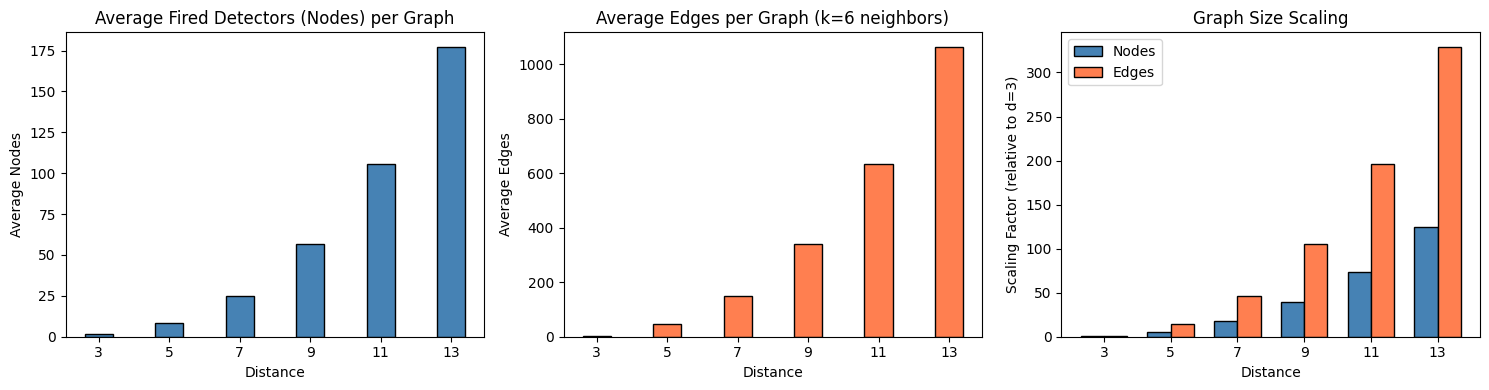

In [11]:
# Plot graph size scaling
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Nodes
ax = axes[0]
nodes = [graph_stats[d]['avg_nodes'] for d in DISTANCES]
ax.bar(DISTANCES, nodes, color='steelblue', edgecolor='black')
ax.set_xlabel('Distance')
ax.set_ylabel('Average Nodes')
ax.set_title('Average Fired Detectors (Nodes) per Graph')
ax.set_xticks(DISTANCES)

# Edges
ax = axes[1]
edges = [graph_stats[d]['avg_edges'] for d in DISTANCES]
ax.bar(DISTANCES, edges, color='coral', edgecolor='black')
ax.set_xlabel('Distance')
ax.set_ylabel('Average Edges')
ax.set_title('Average Edges per Graph (k=6 neighbors)')
ax.set_xticks(DISTANCES)

# Scaling relative to d=3
ax = axes[2]
base_nodes = graph_stats[3]['avg_nodes']
base_edges = graph_stats[3]['avg_edges']
node_scaling = [graph_stats[d]['avg_nodes'] / base_nodes for d in DISTANCES]
edge_scaling = [graph_stats[d]['avg_edges'] / base_edges for d in DISTANCES]
x = np.arange(len(DISTANCES))
width = 0.35
ax.bar(x - width/2, node_scaling, width, label='Nodes', color='steelblue', edgecolor='black')
ax.bar(x + width/2, edge_scaling, width, label='Edges', color='coral', edgecolor='black')
ax.set_xlabel('Distance')
ax.set_ylabel('Scaling Factor (relative to d=3)')
ax.set_title('Graph Size Scaling')
ax.set_xticks(x)
ax.set_xticklabels(DISTANCES)
ax.legend()

plt.tight_layout()
plt.savefig('graph_size_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Forward Pass Profiling

Profile each component of the forward pass to identify bottlenecks.

In [12]:
def profile_forward_pass(model: GraphSAGEModel, data_loader: DataLoader, 
                         num_batches: int = 50) -> Dict[str, float]:
    """
    Profile each component of the forward pass.
    Returns timing breakdown in milliseconds.
    """
    model.eval()
    
    timings = {
        'data_transfer': [],
        'conv_layers': [],
        'batch_norm': [],
        'activation': [],
        'global_pooling': [],
        'fc_layers': [],
        'total': []
    }
    
    with torch.no_grad():
        for i, data in enumerate(data_loader):
            if i >= num_batches:
                break
            
            # Warm-up GPU
            if i == 0:
                data = data.to(device)
                _ = model(data)
                torch.cuda.synchronize()
                continue
            
            torch.cuda.synchronize()
            t_start = time.perf_counter()
            
            # Data transfer
            t0 = time.perf_counter()
            data = data.to(device)
            torch.cuda.synchronize()
            timings['data_transfer'].append((time.perf_counter() - t0) * 1000)
            
            x, edge_index = data.x, data.edge_index
            edge_weight = data.edge_attr.view(-1) if data.edge_attr is not None else None
            batch = data.batch if data.batch is not None else torch.zeros(x.size(0), dtype=torch.long, device=device)
            
            # Conv layers (combined timing)
            t0 = time.perf_counter()
            for conv, bn in zip(model.convs, model.bns):
                x = conv(x, edge_index, edge_weight)
                x = bn(x)
                x = F.silu(x)
            torch.cuda.synchronize()
            timings['conv_layers'].append((time.perf_counter() - t0) * 1000)
            
            # Global pooling (THE BOTTLENECK)
            t0 = time.perf_counter()
            batch_size = int(data.num_graphs) if hasattr(data, 'num_graphs') else int(batch.max().item()) + 1
            x_pooled = torch.zeros(batch_size, x.size(1), device=device)
            for j in range(batch_size):
                mask = (batch == j)
                if mask.sum() > 0:
                    x_pooled[j] = x[mask].mean(dim=0)
            torch.cuda.synchronize()
            timings['global_pooling'].append((time.perf_counter() - t0) * 1000)
            
            # FC layers
            t0 = time.perf_counter()
            x_out = model.fc1(x_pooled)
            x_out = F.silu(x_out)
            x_out = model.fc2(x_out)
            x_out = torch.sigmoid(x_out)
            torch.cuda.synchronize()
            timings['fc_layers'].append((time.perf_counter() - t0) * 1000)
            
            torch.cuda.synchronize()
            timings['total'].append((time.perf_counter() - t_start) * 1000)
    
    # Compute statistics
    results = {}
    for key, values in timings.items():
        if values:
            results[key] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'min': np.min(values),
                'max': np.max(values)
            }
    
    return results

In [13]:
# Profile forward pass for each distance
BATCH_SIZE = 64
NUM_SAMPLES = 5000

profiling_results = {}

for d in DISTANCES:
    if d not in models:
        continue
        
    print(f"\nProfiling d={d}...")
    
    # Generate test data
    sampler = SurfaceCodeSampler(p=0.005, device=device)
    detections_batch, labels_batch = sampler.sample(d=d, num_samples=NUM_SAMPLES)
    graphs = []
    for i in tqdm(range(NUM_SAMPLES), desc="Converting to graphs"):
        graph = graph_builder.to_pyg(detections_batch[i], labels_batch[i])
        graphs.append(graph)
    
    loader = DataLoader(graphs, batch_size=BATCH_SIZE, shuffle=False)
    
    # Profile
    results = profile_forward_pass(models[d].model, loader)
    profiling_results[d] = results
    
    # Print results
    print(f"\nForward pass timing (batch={BATCH_SIZE}):")
    for key, stats in results.items():
        print(f"  {key:20s}: {stats['mean']:7.3f} ± {stats['std']:5.3f} ms")


Profiling d=3...
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)


Converting to graphs: 100%|██████████| 5000/5000 [00:01<00:00, 4732.12it/s]



Forward pass timing (batch=64):
  data_transfer       :   0.255 ± 0.455 ms
  conv_layers         :   1.474 ± 0.344 ms
  global_pooling      :  10.175 ± 2.519 ms
  fc_layers           :   0.201 ± 0.086 ms
  total               :  12.127 ± 2.842 ms

Profiling d=5...
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)


Converting to graphs: 100%|██████████| 5000/5000 [00:01<00:00, 3559.16it/s]



Forward pass timing (batch=64):
  data_transfer       :   0.182 ± 0.094 ms
  conv_layers         :   1.550 ± 0.473 ms
  global_pooling      :  14.876 ± 2.570 ms
  fc_layers           :   0.207 ± 0.058 ms
  total               :  16.839 ± 2.797 ms

Profiling d=7...
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)


...


Forward pass timing (batch=64):
  data_transfer       :   0.340 ± 0.289 ms
  conv_layers         :   1.873 ± 1.158 ms
  global_pooling      :  14.724 ± 2.343 ms
  fc_layers           :   0.212 ± 0.094 ms
  total               :  17.174 ± 3.367 ms

Profiling d=11...
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)


Converting to graphs: 100%|██████████| 5000/5000 [00:03<00:00, 1522.61it/s]



Forward pass timing (batch=64):
  data_transfer       :   0.310 ± 0.054 ms
  conv_layers         :   1.580 ± 0.473 ms
  global_pooling      :  15.313 ± 2.540 ms
  fc_layers           :   0.199 ± 0.055 ms
  total               :  17.428 ± 2.923 ms

Profiling d=13...
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)


Converting to graphs: 100%|██████████| 5000/5000 [00:05<00:00, 999.78it/s] 



Forward pass timing (batch=64):
  data_transfer       :   0.445 ± 0.102 ms
  conv_layers         :   2.129 ± 0.561 ms
  global_pooling      :  18.763 ± 4.096 ms
  fc_layers           :   0.244 ± 0.089 ms
  total               :  21.611 ± 4.560 ms


In [14]:
# Create timing breakdown table
print("\n" + "="*80)
print("TIMING BREAKDOWN (ms per batch of 64)")
print("="*80)

components = ['data_transfer', 'conv_layers', 'global_pooling', 'fc_layers', 'total']

rows = []
for d in DISTANCES:
    if d not in profiling_results:
        continue
    row = {'Distance': d}
    for comp in components:
        if comp in profiling_results[d]:
            row[comp] = profiling_results[d][comp]['mean']
    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index('Distance')

# Add percentage columns
for comp in components[:-1]:  # exclude total
    if comp in df.columns:
        df[f'{comp}_pct'] = 100 * df[comp] / df['total']

print(df.to_string())


TIMING BREAKDOWN (ms per batch of 64)
          data_transfer  conv_layers  global_pooling  fc_layers      total  data_transfer_pct  conv_layers_pct  global_pooling_pct  fc_layers_pct
Distance                                                                                                                                         
3              0.254963     1.473865       10.175208   0.200594  12.126702           2.102495        12.153884           83.907464       1.654150
5              0.182335     1.550500       14.875871   0.206904  16.839222           1.082798         9.207670           88.340608       1.228703
7              0.203473     1.638865       14.766116   0.194600  16.828122           1.209128         9.738848           87.746666       1.156398
9              0.339714     1.872584       14.723520   0.212116  17.173969           1.978077        10.903616           85.731610       1.235104
11             0.310394     1.580022       15.312608   0.198600  17.428227           

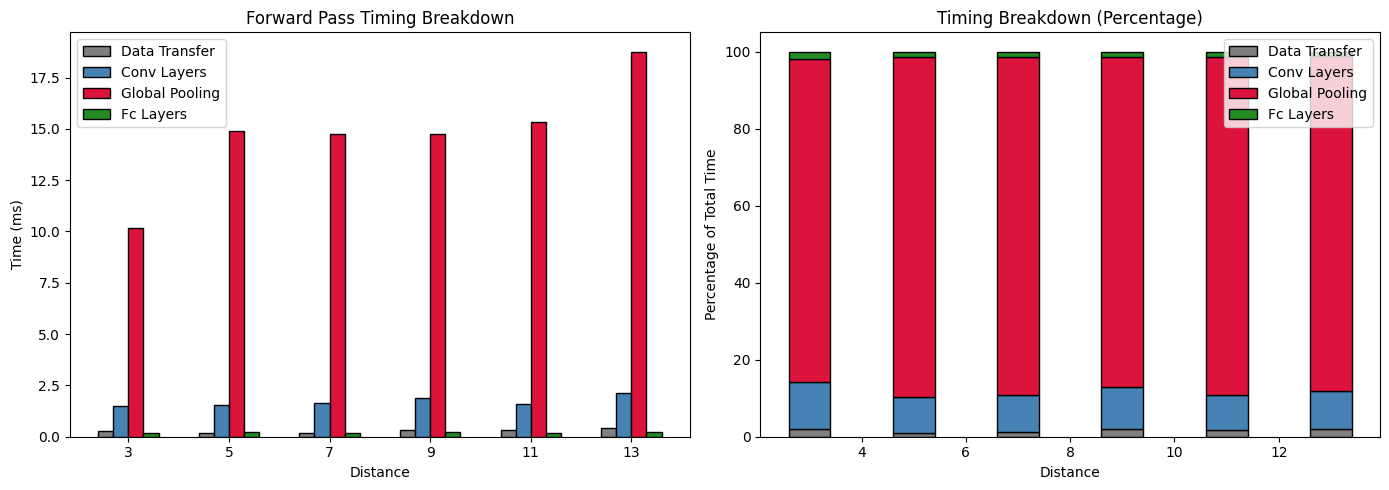

In [15]:
# Visualize timing breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute timing
ax = axes[0]
distances_with_data = [d for d in DISTANCES if d in profiling_results]
x = np.arange(len(distances_with_data))
width = 0.15

colors = {'data_transfer': 'gray', 'conv_layers': 'steelblue', 
          'global_pooling': 'crimson', 'fc_layers': 'forestgreen'}

for i, comp in enumerate(['data_transfer', 'conv_layers', 'global_pooling', 'fc_layers']):
    values = [profiling_results[d][comp]['mean'] for d in distances_with_data]
    ax.bar(x + i*width, values, width, label=comp.replace('_', ' ').title(), 
           color=colors[comp], edgecolor='black')

ax.set_xlabel('Distance')
ax.set_ylabel('Time (ms)')
ax.set_title('Forward Pass Timing Breakdown')
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(distances_with_data)
ax.legend()

# Percentage breakdown (stacked)
ax = axes[1]
bottom = np.zeros(len(distances_with_data))
for comp in ['data_transfer', 'conv_layers', 'global_pooling', 'fc_layers']:
    values = [100*profiling_results[d][comp]['mean']/profiling_results[d]['total']['mean'] 
              for d in distances_with_data]
    ax.bar(distances_with_data, values, bottom=bottom, label=comp.replace('_', ' ').title(),
           color=colors[comp], edgecolor='black')
    bottom += values

ax.set_xlabel('Distance')
ax.set_ylabel('Percentage of Total Time')
ax.set_title('Timing Breakdown (Percentage)')
ax.legend(loc='upper right')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('timing_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Global Pooling Bottleneck Analysis

The current implementation uses a Python for-loop for global pooling:
```python
for i in range(batch_size):
    mask = (batch == i)
    if mask.sum() > 0:
        x_pooled[i] = x[mask].mean(dim=0)
```

This is **extremely slow** compared to PyTorch Geometric's optimized `global_mean_pool`.

In [21]:
def benchmark_pooling_methods(x: torch.Tensor, batch: torch.Tensor, 
                               batch_size: int, num_iterations: int = 100) -> Dict[str, float]:
    """
    Compare different global pooling implementations.
    """
    results = {}
    
    # Method 1: Current (for-loop)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(num_iterations):
        x_pooled = torch.zeros(batch_size, x.size(1), device=device)
        for i in range(batch_size):
            mask = (batch == i)
            if mask.sum() > 0:
                x_pooled[i] = x[mask].mean(dim=0)
    torch.cuda.synchronize()
    results['for_loop'] = (time.perf_counter() - t0) * 1000 / num_iterations
    
    # Method 2: PyG global_mean_pool (optimized C++/CUDA)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(num_iterations):
        x_pooled = global_mean_pool(x, batch, size=batch_size)
    torch.cuda.synchronize()
    results['global_mean_pool'] = (time.perf_counter() - t0) * 1000 / num_iterations
    
    return results

In [22]:
# Benchmark pooling methods for each distance
print("Benchmarking pooling methods...")
print("="*70)

pooling_benchmarks = {}

for d in DISTANCES:
    if d not in models:
        continue
    
    # Generate sample batch
    sampler = SurfaceCodeSampler(p=0.005, device=device)
    detections_batch, labels_batch = sampler.sample(d=d, num_samples=BATCH_SIZE)
    graphs = []
    for i in range(BATCH_SIZE):
        graph = graph_builder.to_pyg(detections_batch[i], labels_batch[i])
        graphs.append(graph)
    
    loader = DataLoader(graphs, batch_size=BATCH_SIZE)
    batch_data = next(iter(loader)).to(device)
    
    # Run model up to pooling point
    model = models[d].model
    model.eval()
    with torch.no_grad():
        x = batch_data.x
        edge_index = batch_data.edge_index
        edge_weight = batch_data.edge_attr.view(-1) if batch_data.edge_attr is not None else None
        batch = batch_data.batch
        
        for conv, bn in zip(model.convs, model.bns):
            x = conv(x, edge_index, edge_weight)
            x = bn(x)
            x = F.silu(x)
    
    # Benchmark pooling
    results = benchmark_pooling_methods(x, batch, BATCH_SIZE)
    pooling_benchmarks[d] = results
    
    speedup = results['for_loop'] / results['global_mean_pool']
    print(f"d={d:2d}: for_loop={results['for_loop']:.3f}ms, "
          f"global_mean_pool={results['global_mean_pool']:.3f}ms, "
          f"speedup={speedup:.1f}x")

Benchmarking pooling methods...
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)
d= 3: for_loop=9.439ms, global_mean_pool=0.071ms, speedup=133.6x
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)
d= 5: for_loop=12.855ms, global_mean_pool=0.068ms, speedup=190.3x
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)
d= 7: for_loop=13.446ms, global_mean_pool=0.073ms, speedup=183.9x
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)
d= 9: for_loop=14.692ms, global_mean_pool=0.082ms, speedup=179.8x
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)
d=11: for_loop=14.897ms, global_mean_pool=0.079ms, speedup=188.3x
SurfaceCodeSampler initialized:
  Defau

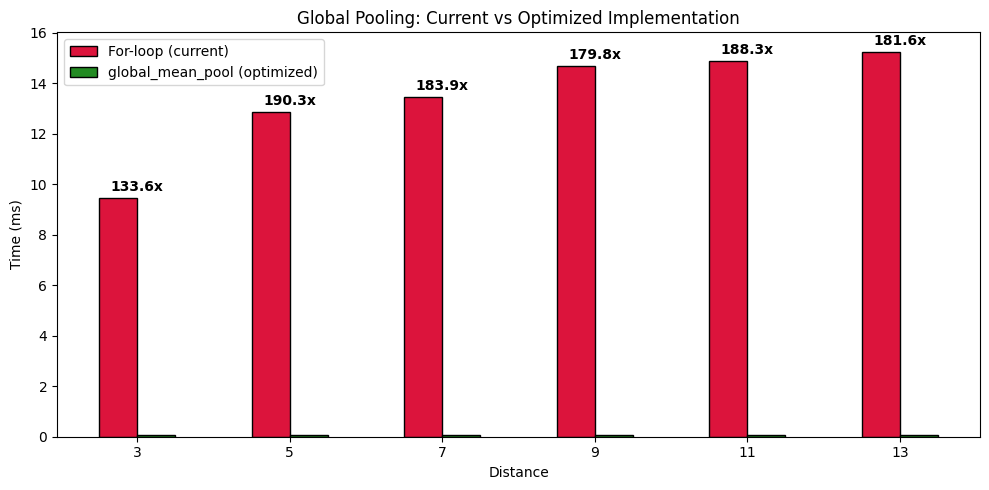

In [23]:
# Visualize pooling speedup
fig, ax = plt.subplots(figsize=(10, 5))

distances_with_data = [d for d in DISTANCES if d in pooling_benchmarks]
x = np.arange(len(distances_with_data))
width = 0.25

for_loop = [pooling_benchmarks[d]['for_loop'] for d in distances_with_data]
global_pool = [pooling_benchmarks[d]['global_mean_pool'] for d in distances_with_data]

ax.bar(x - width/2, for_loop, width, label='For-loop (current)', color='crimson', edgecolor='black')
ax.bar(x + width/2, global_pool, width, label='global_mean_pool (optimized)', color='forestgreen', edgecolor='black')

ax.set_xlabel('Distance')
ax.set_ylabel('Time (ms)')
ax.set_title('Global Pooling: Current vs Optimized Implementation')
ax.set_xticks(x)
ax.set_xticklabels(distances_with_data)
ax.legend()

# Add speedup annotations
for i, d in enumerate(distances_with_data):
    speedup = pooling_benchmarks[d]['for_loop'] / pooling_benchmarks[d]['global_mean_pool']
    ax.annotate(f'{speedup:.1f}x', xy=(i, for_loop[i]), 
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('pooling_speedup.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Conv Layer Analysis

Analyze the message passing overhead in each GraphSAGE layer.

In [24]:
def profile_conv_layers(model: GraphSAGEModel, data, num_iterations: int = 100) -> Dict:
    """
    Profile each conv layer individually.
    """
    model.eval()
    layer_times = {f'layer_{i}': [] for i in range(model.num_layers)}
    
    with torch.no_grad():
        for _ in range(num_iterations):
            x = data.x
            edge_index = data.edge_index
            edge_weight = data.edge_attr.view(-1) if data.edge_attr is not None else None
            
            for i, (conv, bn) in enumerate(zip(model.convs, model.bns)):
                torch.cuda.synchronize()
                t0 = time.perf_counter()
                x = conv(x, edge_index, edge_weight)
                x = bn(x)
                x = F.silu(x)
                torch.cuda.synchronize()
                layer_times[f'layer_{i}'].append((time.perf_counter() - t0) * 1000)
    
    results = {}
    for key, times in layer_times.items():
        results[key] = {'mean': np.mean(times), 'std': np.std(times)}
    
    return results

In [25]:
# Profile conv layers for each distance
conv_profiles = {}

for d in DISTANCES:
    if d not in models:
        continue
    
    # Generate sample batch
    sampler = SurfaceCodeSampler(p=0.005, device=device)
    detections_batch, labels_batch = sampler.sample(d=d, num_samples=BATCH_SIZE)
    graphs = []
    for i in range(BATCH_SIZE):
        graph = graph_builder.to_pyg(detections_batch[i], labels_batch[i])
        graphs.append(graph)
    
    loader = DataLoader(graphs, batch_size=BATCH_SIZE)
    batch_data = next(iter(loader)).to(device)
    
    results = profile_conv_layers(models[d].model, batch_data)
    conv_profiles[d] = results
    
    print(f"\nd={d} - Conv layer timing (ms):")
    for layer, stats in results.items():
        print(f"  {layer}: {stats['mean']:.3f} ± {stats['std']:.3f}")

SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)

d=3 - Conv layer timing (ms):
  layer_0: 0.546 ± 0.490
  layer_1: 0.446 ± 0.264
  layer_2: 0.441 ± 0.206
  layer_3: 0.453 ± 0.231
  layer_4: 0.448 ± 0.233
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)

d=5 - Conv layer timing (ms):
  layer_0: 0.320 ± 0.118
  layer_1: 0.325 ± 0.116
  layer_2: 0.328 ± 0.125
  layer_3: 0.323 ± 0.114
  layer_4: 0.321 ± 0.108
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)

d=7 - Conv layer timing (ms):
  layer_0: 0.419 ± 0.125
  layer_1: 0.408 ± 0.115
  layer_2: 0.407 ± 0.128
  layer_3: 0.400 ± 0.119
  layer_4: 0.404 ± 0.116
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)

d=9 - Conv layer timing (ms):
  layer_0: 0.362 ± 0.

## 7. Summary: Identified Bottlenecks

Based on the profiling, here are the main inference speed bottlenecks:

In [26]:
print("="*80)
print("INFERENCE SPEED BOTTLENECK ANALYSIS SUMMARY")
print("="*80)

print("\n1. GLOBAL POOLING (CRITICAL BOTTLENECK)")
print("-" * 50)
print("   Current implementation uses a Python for-loop:")
print("   ")
print("   for i in range(batch_size):")
print("       mask = (batch == i)")
print("       x_pooled[i] = x[mask].mean(dim=0)")
print("   ")
print("   This is EXTREMELY slow compared to PyG's optimized global_mean_pool.")
print("   ")

if pooling_benchmarks:
    avg_speedup = np.mean([pooling_benchmarks[d]['for_loop'] / pooling_benchmarks[d]['global_mean_pool'] 
                          for d in pooling_benchmarks])
    print(f"   Average speedup with global_mean_pool: {avg_speedup:.1f}x")
    print("   ")
    
    for d in DISTANCES:
        if d in pooling_benchmarks and d in profiling_results:
            pool_time = profiling_results[d]['global_pooling']['mean']
            total_time = profiling_results[d]['total']['mean']
            pct = 100 * pool_time / total_time
            print(f"   d={d:2d}: Pooling takes {pool_time:.2f}ms ({pct:.0f}% of forward pass)")

print("\n2. GRAPH SIZE SCALING")
print("-" * 50)
if graph_stats:
    print("   Graph complexity increases with distance:")
    print("   ")
    for d in DISTANCES:
        if d in graph_stats:
            s = graph_stats[d]
            print(f"   d={d:2d}: ~{s['avg_nodes']:.0f} nodes, ~{s['avg_edges']:.0f} edges")

print("\n3. CONV LAYER OVERHEAD")
print("-" * 50)
print("   5 WeightedSAGEConv layers with max aggregation.")
print("   Each layer performs message passing over all edges.")
if conv_profiles:
    for d in [3, 13]:  # Compare smallest and largest
        if d in conv_profiles:
            total = sum(conv_profiles[d][f'layer_{i}']['mean'] for i in range(5))
            print(f"   d={d:2d}: Total conv time = {total:.2f}ms")

print("\n" + "="*80)
print("RECOMMENDED OPTIMIZATIONS:")
print("="*80)
print("")
print("1. Replace for-loop pooling with global_mean_pool():")
print("   from torch_geometric.nn import global_mean_pool")
print("   x_pooled = global_mean_pool(x, batch)")
print("")
print("2. Consider reducing number of layers (5 -> 3-4) for larger distances")
print("")
print("3. Consider using a smaller hidden_dim for inference (128 -> 64)")
print("")
print("4. Batch size optimization - find optimal batch size for throughput")

INFERENCE SPEED BOTTLENECK ANALYSIS SUMMARY

1. GLOBAL POOLING (CRITICAL BOTTLENECK)
--------------------------------------------------
   Current implementation uses a Python for-loop:
   
   for i in range(batch_size):
       mask = (batch == i)
       x_pooled[i] = x[mask].mean(dim=0)
   
   This is EXTREMELY slow compared to PyG's optimized global_mean_pool.
   
   Average speedup with global_mean_pool: 176.2x
   
   d= 3: Pooling takes 10.18ms (84% of forward pass)
   d= 5: Pooling takes 14.88ms (88% of forward pass)
   d= 7: Pooling takes 14.77ms (88% of forward pass)
   d= 9: Pooling takes 14.72ms (86% of forward pass)
   d=11: Pooling takes 15.31ms (88% of forward pass)
   d=13: Pooling takes 18.76ms (87% of forward pass)

2. GRAPH SIZE SCALING
--------------------------------------------------
   Graph complexity increases with distance:
   
   d= 3: ~1 nodes, ~3 edges
   d= 5: ~8 nodes, ~47 edges
   d= 7: ~25 nodes, ~149 edges
   d= 9: ~57 nodes, ~341 edges
   d=11: ~105 node

## 8. Projected Speedup with global_mean_pool Fix

In [27]:
# Calculate projected inference times after fixing the pooling bottleneck
print("\nProjected inference times with global_mean_pool fix:")
print("="*70)

projected_results = []

for d in DISTANCES:
    if d not in profiling_results or d not in pooling_benchmarks:
        continue
    
    current_total = profiling_results[d]['total']['mean']
    current_pooling = profiling_results[d]['global_pooling']['mean']
    new_pooling = pooling_benchmarks[d]['global_mean_pool']
    
    # Projected total = current_total - current_pooling + new_pooling
    projected_total = current_total - current_pooling + new_pooling
    speedup = current_total / projected_total
    
    projected_results.append({
        'distance': d,
        'current_ms': current_total,
        'projected_ms': projected_total,
        'speedup': speedup,
        'current_throughput': BATCH_SIZE * 1000 / current_total,
        'projected_throughput': BATCH_SIZE * 1000 / projected_total,
    })
    
    print(f"d={d:2d}: {current_total:.2f}ms -> {projected_total:.2f}ms ({speedup:.2f}x speedup)")
    print(f"       Throughput: {BATCH_SIZE*1000/current_total:.0f} -> {BATCH_SIZE*1000/projected_total:.0f} samples/sec")

# Save results
proj_df = pd.DataFrame(projected_results)
proj_df.to_csv('projected_speedup.csv', index=False)
print("\nResults saved to projected_speedup.csv")


Projected inference times with global_mean_pool fix:
d= 3: 12.13ms -> 2.02ms (6.00x speedup)
       Throughput: 5278 -> 31649 samples/sec
d= 5: 16.84ms -> 2.03ms (8.29x speedup)
       Throughput: 3801 -> 31513 samples/sec
d= 7: 16.83ms -> 2.14ms (7.88x speedup)
       Throughput: 3803 -> 29975 samples/sec
d= 9: 17.17ms -> 2.53ms (6.78x speedup)
       Throughput: 3727 -> 25275 samples/sec
d=11: 17.43ms -> 2.19ms (7.94x speedup)
       Throughput: 3672 -> 29161 samples/sec
d=13: 21.61ms -> 2.93ms (7.37x speedup)
       Throughput: 2961 -> 21822 samples/sec

Results saved to projected_speedup.csv


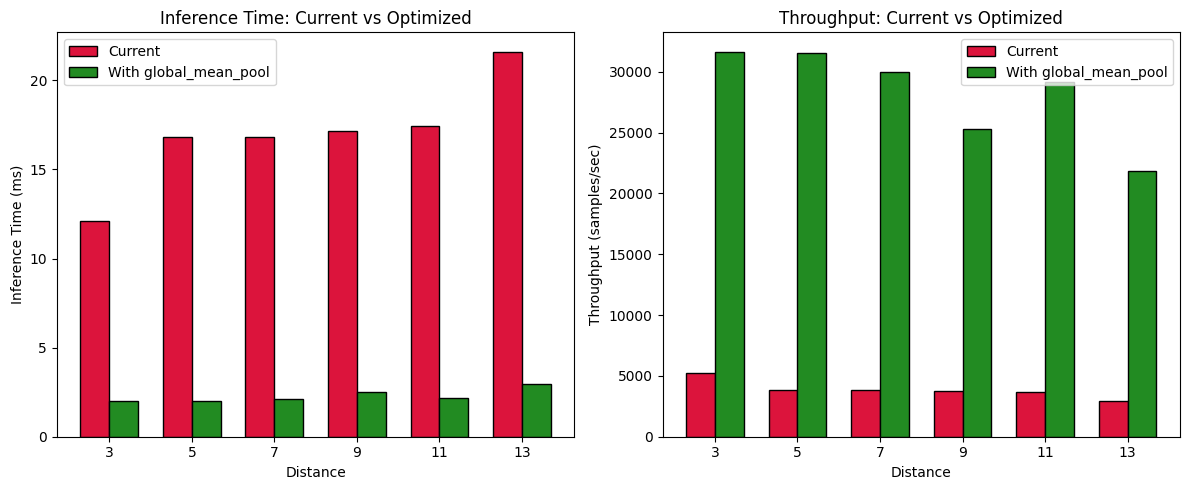

In [28]:
# Visualize projected speedup
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

proj_df = pd.DataFrame(projected_results)

# Inference time comparison
ax = axes[0]
x = np.arange(len(proj_df))
width = 0.35
ax.bar(x - width/2, proj_df['current_ms'], width, label='Current', color='crimson', edgecolor='black')
ax.bar(x + width/2, proj_df['projected_ms'], width, label='With global_mean_pool', color='forestgreen', edgecolor='black')
ax.set_xlabel('Distance')
ax.set_ylabel('Inference Time (ms)')
ax.set_title('Inference Time: Current vs Optimized')
ax.set_xticks(x)
ax.set_xticklabels(proj_df['distance'])
ax.legend()

# Throughput comparison
ax = axes[1]
ax.bar(x - width/2, proj_df['current_throughput'], width, label='Current', color='crimson', edgecolor='black')
ax.bar(x + width/2, proj_df['projected_throughput'], width, label='With global_mean_pool', color='forestgreen', edgecolor='black')
ax.set_xlabel('Distance')
ax.set_ylabel('Throughput (samples/sec)')
ax.set_title('Throughput: Current vs Optimized')
ax.set_xticks(x)
ax.set_xticklabels(proj_df['distance'])
ax.legend()

plt.tight_layout()
plt.savefig('projected_speedup.png', dpi=150, bbox_inches='tight')
plt.show()